# Seaborn

- 설치
    - !pip install 
- api
    - https://matplotlib.org/stable/gallery/index.html
    - https://seaborn.pydata.org/

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns                      # 통계 전용 시각화 - matplotlib 같이 사용 가능 

import matplotlib.pyplot as plt            # 그래프 출력 옵션 (Detail)
import matplotlib as mpl                   # 외적인(큰틀) 옵션 - 한글, 사이즈 등  

mpl.rc('font', family='Malgun Gothic')     # 폰트 경로 - C:\Windows\Fonts\Malgun Gothic
plt.rcParams['axes.unicode_minus']=False   # 마이너스 설정 

## 단일 변수 : 한 가지 항목에 대한 시각화
### 범주형(문자형) - countplot, pie
* 항목과 빈도수
* Bar(countplot), Pie(matplotlib Pie)

In [9]:
dye=pd.read_csv('./Data_Set/염색공정_수정.csv', encoding='cp949')
dye.shape

(32608, 9)

In [12]:
dye.head()

,설비번호,투입중량_kg,염색길이_m,투입중량/길이,지시온도,진행온도,공정진행시간_%,염색색차_DE,불량여부
0,FCM08,44.6,41.0,1.087805,30.0,10.9,0.19,0.753096,0
1,FCM08,44.6,41.0,1.087805,30.0,10.3,0.39,0.753096,0
2,FCM08,44.6,41.0,1.087805,30.0,10.3,0.58,0.753096,0
3,FCM08,44.6,41.0,1.087805,30.0,10.2,0.77,0.753096,0
4,FCM08,44.6,41.0,1.087805,30.0,10.8,0.97,0.753096,0


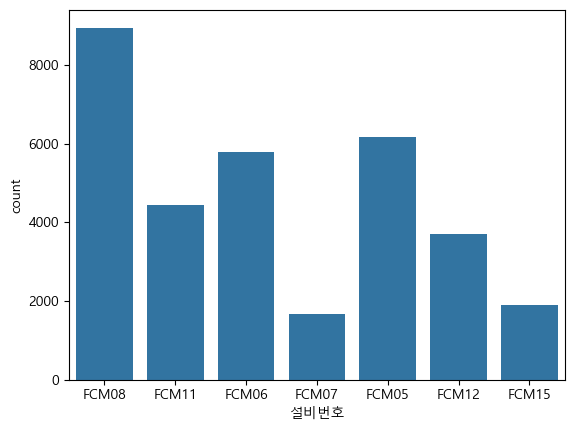

In [14]:
sns.countplot(data=dye, x='설비번호')   
plt.show()

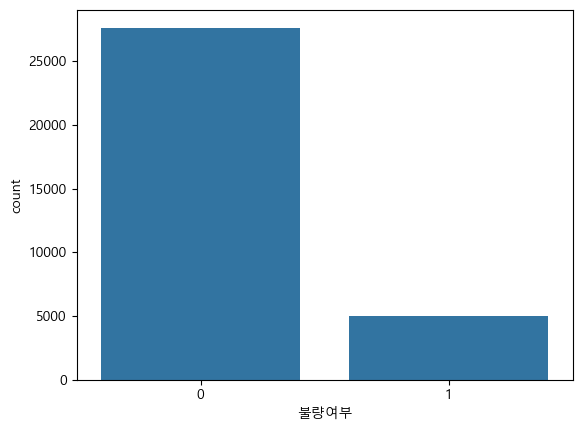

In [16]:
sns.countplot(data=dye, x='불량여부')   
plt.show()

### 옵션지정 - matplotlib

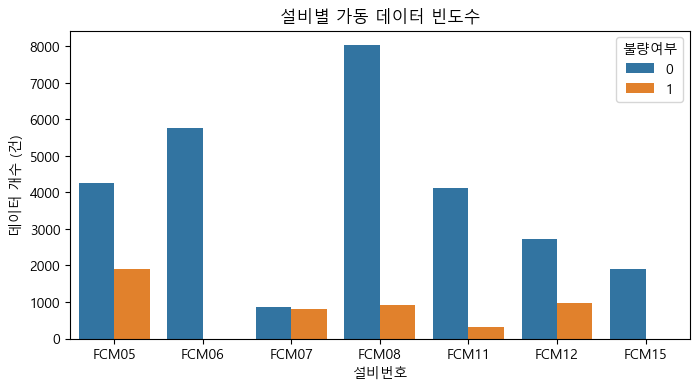

In [19]:
plt.figure(figsize=(8, 4))
plt.title('설비별 가동 데이터 빈도수')
plt.xlabel('설비번호')
plt.ylabel('데이터 개수 (건)')

order_list=sorted(dye['설비번호'].unique())  
sns.countplot(data=dye, x='설비번호', hue='불량여부', order=order_list)
plt.show() 

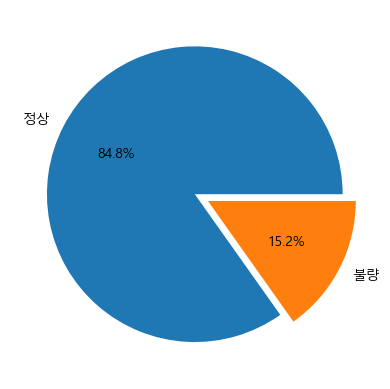

In [21]:
# plt.pie(값 리스트, labels=레이블 리스트)
num=dye['불량여부'].value_counts()

plt.pie(x=num.values, 
        # labels=num.index,
        labels=['정상', '불량'],
        autopct='%.1f%%', 
        explode=[0, 0.1])     
plt.show()

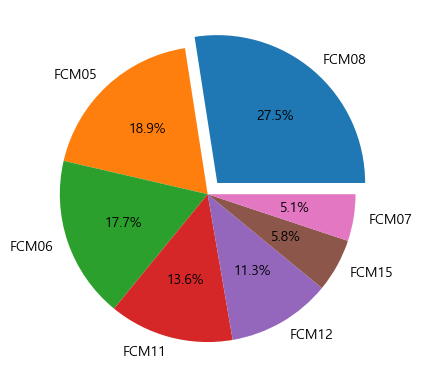

In [23]:
num=dye['설비번호'].value_counts()

plt.pie(x=num.values, 
        labels=num.index,
        autopct='%.1f%%', 
        explode=[0.1, 0, 0, 0, 0, 0, 0])
plt.show()

### 연속형(숫자형) - histplot, boxplot
* histplot(Histogram), boxplot
* 분포의 모양과 확률 밀도
* Histogram, Box Plot 

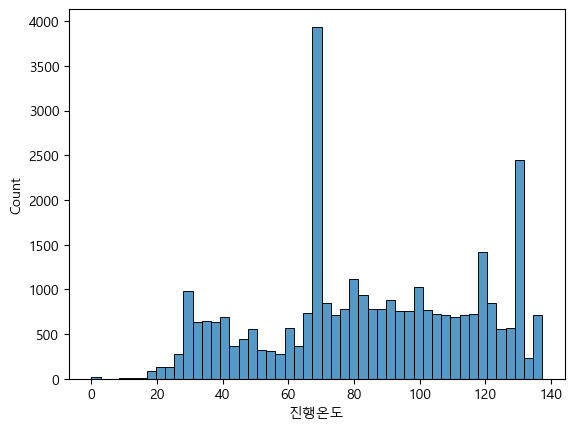

In [35]:
sns.histplot(data=dye, x='진행온도')
plt.show()

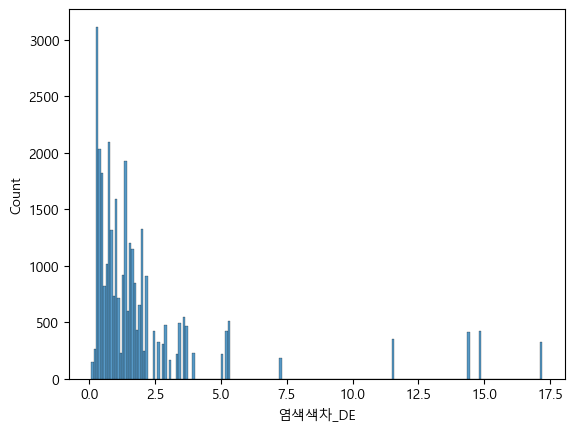

In [37]:
sns.histplot(data=dye, x='염색색차_DE')
plt.show()

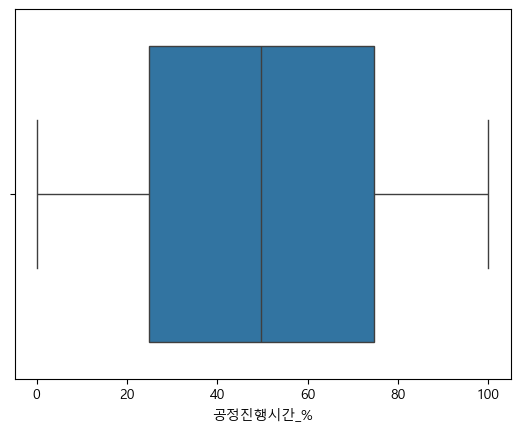

In [39]:
sns.boxplot(data=dye, x='공정진행시간_%')
plt.show()

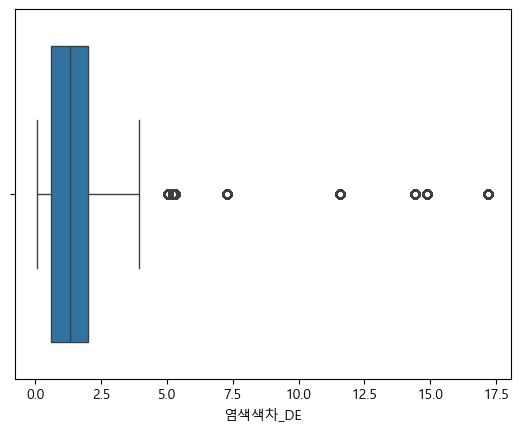

In [41]:
sns.boxplot(data=dye, x='염색색차_DE')
plt.show()

## 다 변수 : 두 변수 간 관계 대한 시각화
### X(문자형) / Y(숫자형) - barplot
- 집단간 통계량 비교
- Bar Char(막대 그래프), Box Plot
- 가장 많이 사용하는 형태 : 연령에 따른 매출 평균, 학년에 따른 평균 키

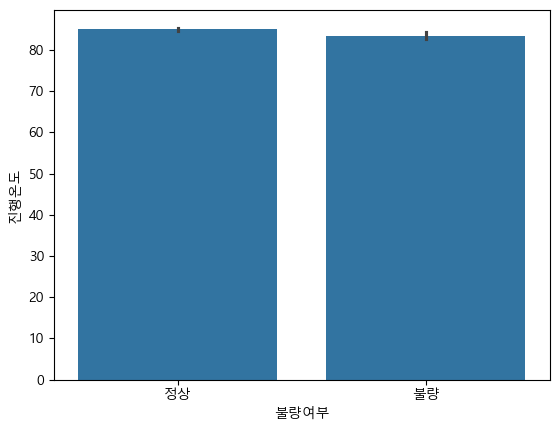

In [11]:
sns.barplot(data=dye, x='불량여부', y='진행온도')
plt.xticks([0, 1], ['정상', '불량'])
plt.show()

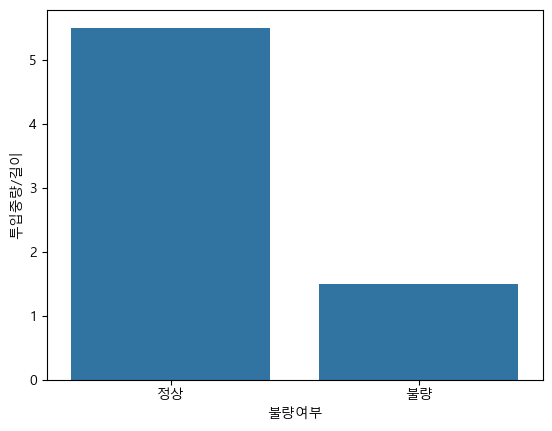

In [54]:
sns.barplot(data=dye, x='불량여부', y='투입중량/길이', errorbar=None)
plt.xticks([0, 1], ['정상', '불량'])
plt.show()

### X(숫자형) / Y(숫자형) - scatter
- 두 데이터의 상관성 (비례 - 반비례)
- Scatter Char(산점도), 회귀선, 히트맵

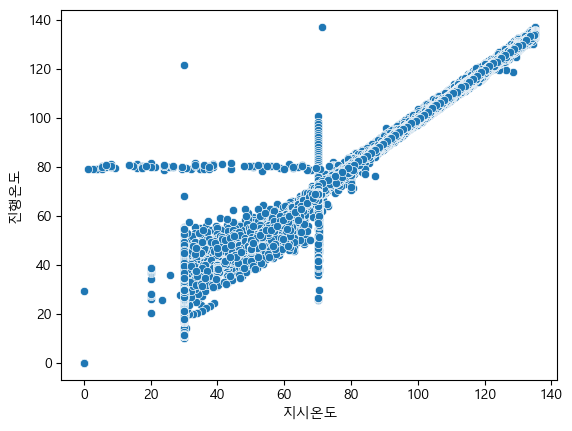

In [59]:
sns.scatterplot(data=dye, x='지시온도', y='진행온도')
plt.show()

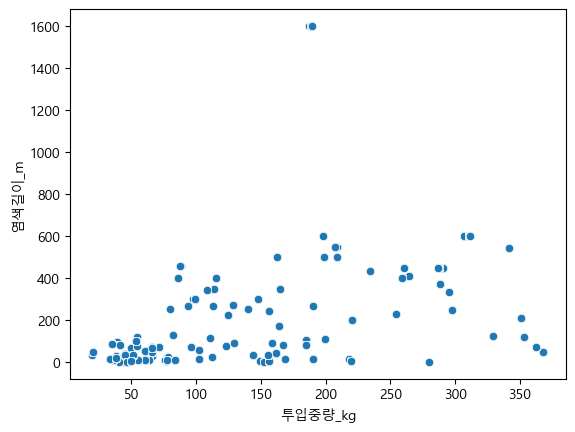

In [42]:
sns.scatterplot(data=dye, x='투입중량_kg', y='염색길이_m')
plt.show()

In [17]:
num_corr=dye.corr(numeric_only=True)
num_corr

,투입중량_kg,염색길이_m,투입중량/길이,지시온도,진행온도,공정진행시간_%,염색색차_DE,불량여부
투입중량_kg,1.000000,0.384291,0.094668,-0.081318,-0.078411,0.005063,-0.096840,0.038306
염색길이_m,0.384291,1.000000,-0.204173,-0.036038,-0.024584,0.007763,-0.145832,-0.053177
투입중량/길이,0.094668,-0.204173,1.000000,0.006088,0.004383,0.000597,-0.074411,-0.104150
지시온도,-0.081318,-0.036038,0.006088,1.000000,0.990602,-0.033886,0.008458,-0.017083
진행온도,-0.078411,-0.024584,0.004383,0.990602,1.000000,-0.027636,0.005894,-0.017951
공정진행시간_%,0.005063,0.007763,0.000597,-0.033886,-0.027636,1.000000,0.004950,0.005738
염색색차_DE,-0.096840,-0.145832,-0.074411,0.008458,0.005894,0.004950,1.000000,0.747326
불량여부,0.038306,-0.053177,-0.104150,-0.017083,-0.017951,0.005738,0.747326,1.000000


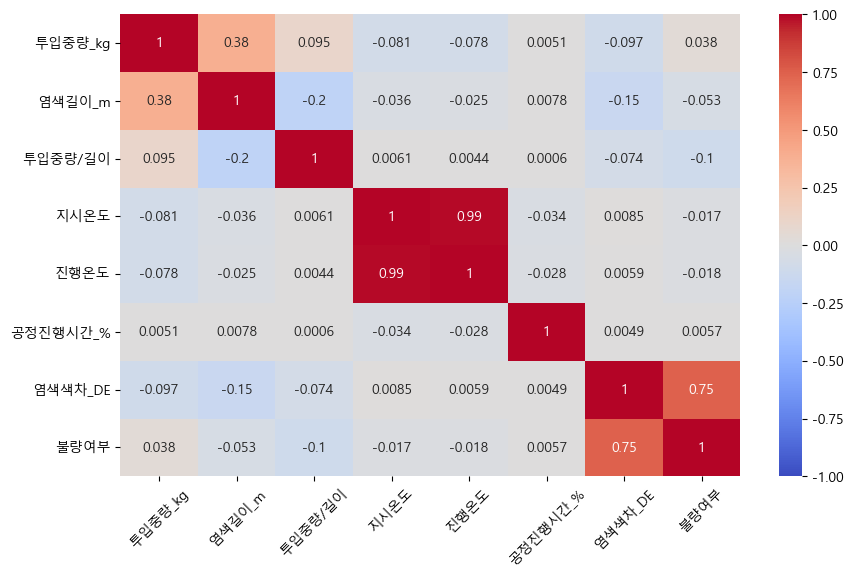

In [20]:
# sns.heatmap(num_corr, annot=True)
# sns.heatmap(num_corr, annot=True, cmap='coolwarm')
plt.figure(figsize=(10, 6))
sns.heatmap(num_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.xticks(rotation=45)
plt.show()

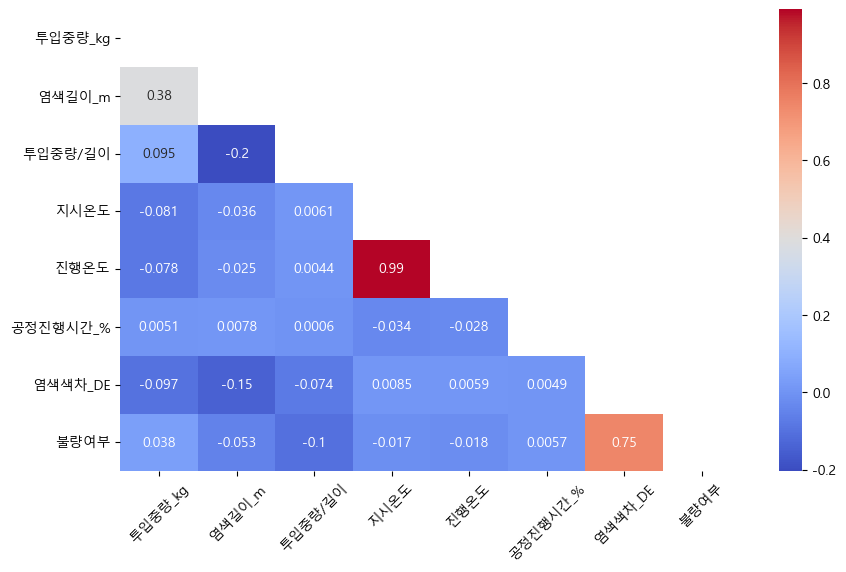

In [22]:
plt.figure(figsize=(10, 6))
sns.heatmap(num_corr,
            annot=True, 
            cmap='coolwarm', 
            mask=np.triu(np.ones_like(num_corr, dtype=bool)))
plt.xticks(rotation=45)
plt.show()

In [32]:
np.ones_like(num_corr, dtype=bool)            # 데이터프레임과 똑같은 크기의 'True'로 가득 찬 행렬

array([[ True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True]])

In [34]:
np.triu(np.ones_like(num_corr, dtype=bool))   # 위쪽 삼각형 부분만 남기고 나머지는 False로 바꿉

array([[ True,  True,  True,  True,  True,  True,  True,  True],
       [False,  True,  True,  True,  True,  True,  True,  True],
       [False, False,  True,  True,  True,  True,  True,  True],
       [False, False, False,  True,  True,  True,  True,  True],
       [False, False, False, False,  True,  True,  True,  True],
       [False, False, False, False, False,  True,  True,  True],
       [False, False, False, False, False, False,  True,  True],
       [False, False, False, False, False, False, False,  True]])

### X(순서형) / Y(숫자형) - lineplot
* 순서(시간)에 따른 연속형 값의 추이
* Line Char(선 그래프)

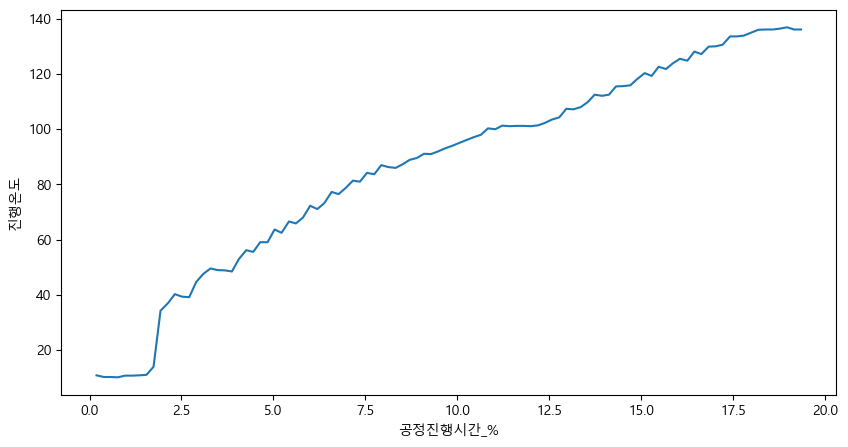

In [79]:
sub_dye=dye[:100]

plt.figure(figsize=(10, 5))
sns.lineplot(data=sub_dye, x='공정진행시간_%', y='진행온도', errorbar=None)
plt.show()

In [ ]:
#  End Of ------------------------------------------------------------------